### What is the most optimal skill to learn for Data Analysts?

In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
df = load_dataset('Lukebarousse/data_jobs')
df = df['train']
df = df.to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [2]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US_exploded = df_DA_US.explode('job_skills')

In [3]:
df_DA_US_exploded = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_US_exploded.rename(columns={'count':'skill_count', 'median':'median_salary'})

total_jobs = len(df_DA_US)

df_DA_skills['skill_percent'] = 100*df_DA_skills['skill_count']/total_jobs

In [4]:
df_DA_skills = df_DA_skills[df_DA_skills['skill_percent'] > 5]
df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


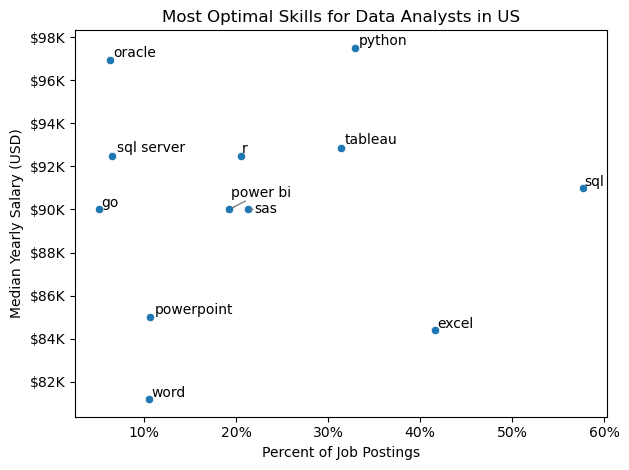

In [5]:
from adjustText import adjust_text

sns.scatterplot(df_DA_skills, x='skill_percent', y='median_salary')

#Prepare texts fro adjustText
texts = []
for txt in df_DA_skills.index:
    texts.append(plt.text(df_DA_skills.loc[txt, 'skill_percent'], df_DA_skills.loc[txt, 'median_salary'], txt))

#Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

#Set axis, labels, title and legend
plt.xlabel('Percent of Job Postings')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Analysts in US')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=False))
#Adjust layout and display plot
plt.tight_layout()
plt.show()

In [6]:
df_technology = df['job_type_skills'].copy()

#Remove duplicates
df_technology = df_technology.drop_duplicates()

#Remove NaN value
df_technology = df_technology.dropna()

#Combine all dictionaries into one
technology_dict  = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key].append(value)
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = [list(t) for t in {tuple(v) for v in value}]
 
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology_exploded = df_technology.explode('skills').explode('skills')

In [7]:
df_plot = df_DA_skills.merge(df_technology_exploded, left_on='job_skills', right_on='skills')

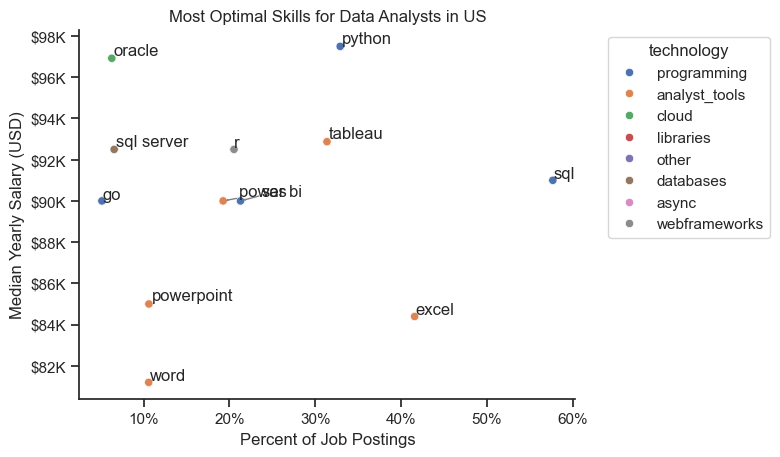

<Figure size 1200x1200 with 0 Axes>

In [20]:
from adjustText import adjust_text

fig = sns.scatterplot(df_plot, 
x='skill_percent', 
y='median_salary',
hue='technology',)

sns.move_legend(fig, 'upper left', bbox_to_anchor=(1.05, 1))
sns.despine()
sns.set_theme(style='ticks')

#Prepare texts fro adjustText
texts = []
for txt in df_DA_skills.index:
    texts.append(plt.text(df_DA_skills.loc[txt, 'skill_percent'], df_DA_skills.loc[txt, 'median_salary'], txt))

#Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

#Set axis, labels, title and legend
plt.xlabel('Percent of Job Postings')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Analysts in US')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K"))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=False))

#Adjust layout and display plot
plt.figure(figsize=(12, 12))
plt.tight_layout()
plt.show()